#### Importing Required Libararies:

In [333]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay
)

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_validate
import time

#### Loading data and preprocessor:

In [334]:
X_train = joblib.load("../data/X_train.pkl")
X_test = joblib.load("../data/X_test.pkl")
y_train = joblib.load("../data/y_train.pkl")
y_test = joblib.load("../data/y_test.pkl")

preprocessor = joblib.load("../outputs/models/preprocessor.pkl")

# Application and Evaluation of different ML models:

I did that because it will prevent the repition of code.

#### Perform Cross Validation:

This function perform cross-validation on the training data.

In [335]:
def perform_cross_validation(pipeline, X_train, y_train):

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    cv_results = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ],
        n_jobs=-1,
        return_train_score=False
    )

    cv_results_df = pd.DataFrame(cv_results)

    cv_results_df = cv_results_df.drop(
        columns=["fit_time", "score_time"]
    )

    return cv_results_df

#### Print Fold-wise Results:

This fuction print fold-wise cross-validation results.

In [336]:
def print_cv_fold_results(cv_results):
    df = pd.DataFrame({
        "Fold": range(1, len(cv_results["test_accuracy"]) + 1),
        "Accuracy": cv_results["test_accuracy"],
        "Precision": cv_results["test_precision"],
        "Recall": cv_results["test_recall"],
        "F1 Score": cv_results["test_f1"],
        "ROC AUC": cv_results["test_roc_auc"]
    })

    return df

#### Print Average Cross Validation Results:

Print average cross-validation metrics.

In [337]:
def print_cv_average_results(cv_results):
    cv_df = pd.DataFrame(cv_results)

    print(f"Accuracy  : {cv_df['test_accuracy'].mean():.4f}")
    print(f"Precision : {cv_df['test_precision'].mean():.4f}")
    print(f"Recall    : {cv_df['test_recall'].mean():.4f}")
    print(f"F1 Score  : {cv_df['test_f1'].mean():.4f}")
    print(f"ROC AUC   : {cv_df['test_roc_auc'].mean():.4f}")

#### Print Standard Deviation:

Print the standard deviation of cross-validation metrics.

In [338]:
def print_cv_standard_deviation(cv_results):

    cv_df = pd.DataFrame(cv_results)


    print(f"Accuracy  : {cv_df['test_accuracy'].std():.4f}")
    print(f"Precision : {cv_df['test_precision'].std():.4f}")
    print(f"Recall    : {cv_df['test_recall'].std():.4f}")
    print(f"F1 Score  : {cv_df['test_f1'].std():.4f}")
    print(f"ROC AUC   : {cv_df['test_roc_auc'].std():.4f}")

#### Fit Pipeline:

This function train the pipeline and record training time.

In [339]:
def fit_pipeline(pipeline, X_train, y_train):
    start_time = time.perf_counter()
    pipeline.fit(X_train, y_train)
    training_time = time.perf_counter() - start_time
    
    return pipeline, training_time

#### Predict:

This function generate predictions on both training and test sets.

In [340]:
def predict_pipeline(pipeline, X_train, X_test):

    train_predictions = pipeline.predict(X_train)
    test_predictions = pipeline.predict(X_test)

    if hasattr(pipeline, "predict_proba"):

        train_probabilities = pipeline.predict_proba(X_train)[:, 1]
        test_probabilities = pipeline.predict_proba(X_test)[:, 1]

    else:

        train_probabilities = None
        test_probabilities = None

    return (
        train_predictions,
        test_predictions,
        train_probabilities,
        test_probabilities
    )

#### Print Test Metrics:

In [341]:
def print_test_metrics(y_test, test_predictions, test_probabilities):

    accuracy = accuracy_score(y_test, test_predictions)
    precision = precision_score(y_test, test_predictions)
    recall = recall_score(y_test, test_predictions)
    f1 = f1_score(y_test, test_predictions)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    metrics = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

    if test_probabilities is not None:
        roc_auc = roc_auc_score(y_test, test_probabilities)

        print(f"ROC AUC   : {roc_auc:.4f}")

        metrics["ROC AUC"] = roc_auc

    return metrics

#### Print Confusion Matrix:

This fuction plots confusion matrix.

In [342]:
def print_confusion_matrix(y_test, test_predictions, model_name):

    fig, ax = plt.subplots(figsize=(2, 2))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        test_predictions,
        ax=ax,
        colorbar=False
    )

    ax.set_title(f"{model_name} - Confusion Matrix")

    plt.tight_layout()
    plt.show()

#### Plot ROC Curve:

This function plot ROC curve if probabilities are available.

In [343]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

def plot_roc_curve(y_test, test_probabilities, model_name):

    fig, ax = plt.subplots(figsize=(3, 3))

    RocCurveDisplay.from_predictions(
        y_test,
        test_probabilities,
        ax=ax
    )

    ax.set_title(f"{model_name} - ROC Curve")

    plt.tight_layout()
    plt.show()

#### Compare Train vs Test Performance:

Compare training and test performance to check for overfitting.

In [344]:
def compare_train_vs_test(y_train, train_predictions, y_test, test_predictions):

    # Training metrics
    train_accuracy = accuracy_score(y_train, train_predictions)
    train_precision = precision_score(y_train, train_predictions)
    train_recall = recall_score(y_train, train_predictions)
    train_f1 = f1_score(y_train, train_predictions)

    # Test metrics
    test_accuracy = accuracy_score(y_test, test_predictions)
    test_precision = precision_score(y_test, test_predictions)
    test_recall = recall_score(y_test, test_predictions)
    test_f1 = f1_score(y_test, test_predictions)

    comparison_df = pd.DataFrame({
        "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
        "Training": [
            train_accuracy,
            train_precision,
            train_recall,
            train_f1
        ],
        "Test": [
            test_accuracy,
            test_precision,
            test_recall,
            test_f1
        ]
    })

    comparison_df["Difference"] = abs(
        comparison_df["Training"] - comparison_df["Test"]
    )

    comparison_df[["Training", "Test", "Difference"]] = comparison_df[
        ["Training", "Test", "Difference"]
    ].round(4)

    return comparison_df

### 1. Random Forest:

In [345]:
random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(
        random_state=42
    ))
])

##### Perform Cross Validation:

In [346]:
cv_results = perform_cross_validation(
    pipeline=random_forest_pipeline,
    X_train=X_train,
    y_train=y_train
)

##### Print Fold-wise CV Results:

In [347]:
print_cv_fold_results(cv_results)

,Fold,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,1,0.989011,1.000000,0.982759,0.991304,0.999739
1,2,0.945055,0.948276,0.964912,0.956522,0.983488
2,3,0.934066,1.000000,0.894737,0.944444,0.985294
3,4,0.923077,0.962963,0.912281,0.936937,0.979876
4,5,0.989011,1.000000,0.982456,0.991150,0.999484


#####  Print Average CV Results:

In [348]:
print_cv_average_results(cv_results)

Accuracy  : 0.9560
Precision : 0.9822
Recall    : 0.9474
F1 Score  : 0.9641
ROC AUC   : 0.9896


##### Print Standard Deviation:

In [349]:
print_cv_standard_deviation(cv_results)

Accuracy  : 0.0311
Precision : 0.0249
Recall    : 0.0412
F1 Score  : 0.0258
ROC AUC   : 0.0094


##### Train the Pipeline:

In [350]:
random_forest_trained_pipeline, training_time = fit_pipeline(
    pipeline=random_forest_pipeline,
    X_train=X_train,
    y_train=y_train
)

print(f"\nTraining Time: {training_time:.4f} seconds")


Training Time: 0.6357 seconds


In [351]:
joblib.dump(random_forest_trained_pipeline, "../outputs/models/random_forest.pkl")

['../outputs/models/random_forest.pkl']

##### Make Predictions:

In [352]:
(
    train_predictions,
    test_predictions,
    train_probabilities,
    test_probabilities
) = predict_pipeline(
    pipeline=trained_pipeline,
    X_train=X_train,
    X_test=X_test
)

##### Print Test Metrics:

In [353]:
metrics = print_test_metrics(
    y_test=y_test,
    test_predictions=test_predictions,
    test_probabilities=test_probabilities
)

Accuracy  : 0.9561
Precision : 0.9714
Recall    : 0.9577
F1 Score  : 0.9645
ROC AUC   : 0.9759


##### Print Confusion Matrix:

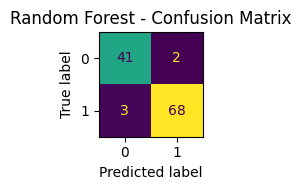

In [354]:
print_confusion_matrix(
    y_test=y_test,
    test_predictions=test_predictions,
    model_name="Random Forest"
)

##### Plot ROC Curve:

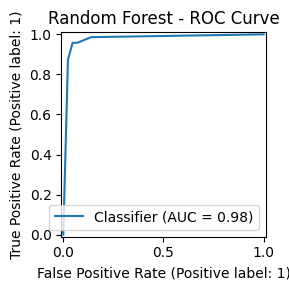

In [355]:
plot_roc_curve(
    y_test=y_test,
    test_probabilities=test_probabilities,
    model_name="Random Forest"
)

##### Compare Training and Test Performance:

In [356]:
compare_train_vs_test(
    y_train=y_train,
    train_predictions=train_predictions,
    y_test=y_test,
    test_predictions=test_predictions
)

,Metric,Training,Test,Difference
0,Accuracy,0.9846,0.9561,0.0285
1,Precision,0.9827,0.9714,0.0113
2,Recall,0.9930,0.9577,0.0353
3,F1 Score,0.9878,0.9645,0.0233


### 2. Logistic Regression:

In [357]:
logistic_regression_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [358]:
cv_results = perform_cross_validation(
    pipeline=logistic_regression_pipeline ,
    X_train=X_train,
    y_train=y_train
)

In [359]:
print_cv_fold_results(cv_results)

,Fold,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,1,0.956044,0.965517,0.965517,0.965517,0.995298
1,2,0.956044,0.964912,0.964912,0.964912,0.985036
2,3,0.978022,1.000000,0.964912,0.982143,0.999484
3,4,0.978022,0.982456,0.982456,0.982456,0.998452
4,5,0.978022,0.982456,0.982456,0.982456,0.997420


In [360]:
print_cv_average_results(cv_results)

Accuracy  : 0.9692
Precision : 0.9791
Recall    : 0.9721
F1 Score  : 0.9755
ROC AUC   : 0.9951


In [361]:
print_cv_standard_deviation(cv_results)

Accuracy  : 0.0120
Precision : 0.0145
Recall    : 0.0095
F1 Score  : 0.0094
ROC AUC   : 0.0059


In [362]:
logistic_regression_trained_pipeline, training_time = fit_pipeline(
    pipeline=logistic_regression_pipeline,
    X_train=X_train,
    y_train=y_train
)

print(f"\nTraining Time: {training_time:.4f} seconds")



Training Time: 0.0477 seconds


In [363]:
joblib.dump(logistic_regression_trained_pipeline, "../outputs/models/logistic_regression.pkl")

['../outputs/models/logistic_regression.pkl']

In [364]:
(
    train_predictions,
    test_predictions,
    train_probabilities,
    test_probabilities
) = predict_pipeline(
    pipeline=trained_pipeline,
    X_train=X_train,
    X_test=X_test
)

In [365]:
metrics = print_test_metrics(
    y_test=y_test,
    test_predictions=test_predictions,
    test_probabilities=test_probabilities
)


Accuracy  : 0.9561
Precision : 0.9714
Recall    : 0.9577
F1 Score  : 0.9645
ROC AUC   : 0.9759


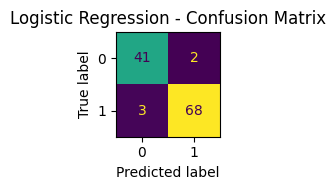

In [366]:
print_confusion_matrix(
    y_test=y_test,
    test_predictions=test_predictions,
    model_name="Logistic Regression"
)

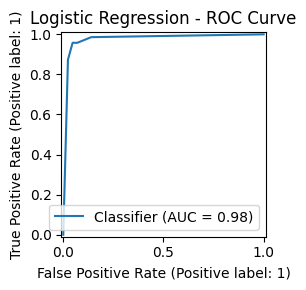

In [367]:
plot_roc_curve(
    y_test=y_test,
    test_probabilities=test_probabilities,
    model_name="Logistic Regression"
)

In [368]:
compare_train_vs_test(
    y_train=y_train,
    train_predictions=train_predictions,
    y_test=y_test,
    test_predictions=test_predictions
)

,Metric,Training,Test,Difference
0,Accuracy,0.9846,0.9561,0.0285
1,Precision,0.9827,0.9714,0.0113
2,Recall,0.9930,0.9577,0.0353
3,F1 Score,0.9878,0.9645,0.0233


### 3. Decision Tree:

In [369]:
decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", DecisionTreeClassifier(
        random_state=42
    ))
])

In [370]:
cv_results = perform_cross_validation(
    pipeline=decision_tree_pipeline,
    X_train=X_train,
    y_train=y_train
)

In [371]:
print_cv_fold_results(cv_results)

,Fold,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,1,0.967033,0.966102,0.982759,0.974359,0.961076
1,2,0.879121,0.883333,0.929825,0.905983,0.861971
2,3,0.890110,0.927273,0.894737,0.910714,0.888545
3,4,0.912088,0.962264,0.894737,0.927273,0.917957
4,5,0.912088,0.915254,0.947368,0.931034,0.900155


In [372]:
print_cv_average_results(cv_results)

Accuracy  : 0.9121
Precision : 0.9308
Recall    : 0.9299
F1 Score  : 0.9299
ROC AUC   : 0.9059


In [373]:
print_cv_standard_deviation(cv_results)

Accuracy  : 0.0339
Precision : 0.0344
Recall    : 0.0373
F1 Score  : 0.0270
ROC AUC   : 0.0369


In [374]:
decision_tree_trained_pipeline, training_time = fit_pipeline(
    pipeline=decision_tree_pipeline,
    X_train=X_train,
    y_train=y_train
)

print(f"Training Time: {training_time:.4f} seconds")

Training Time: 0.0530 seconds


In [375]:
joblib.dump(decision_tree_trained_pipeline, "../outputs/models/decision_tree.pkl")

['../outputs/models/decision_tree.pkl']

In [376]:
(
    train_predictions,
    test_predictions,
    train_probabilities,
    test_probabilities
) = predict_pipeline(
    pipeline=trained_pipeline,
    X_train=X_train,
    X_test=X_test
)

In [377]:
_ = print_test_metrics(
    y_test=y_test,
    test_predictions=test_predictions,
    test_probabilities=test_probabilities
)

Accuracy  : 0.9561
Precision : 0.9714
Recall    : 0.9577
F1 Score  : 0.9645
ROC AUC   : 0.9759


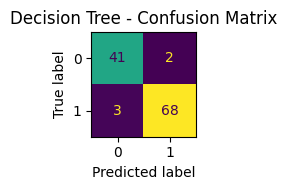

In [378]:
print_confusion_matrix(
    y_test=y_test,
    test_predictions=test_predictions,
    model_name="Decision Tree"
)

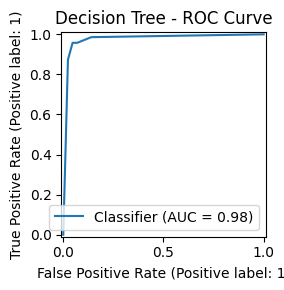

In [379]:
plot_roc_curve(
    y_test=y_test,
    test_probabilities=test_probabilities,
    model_name="Decision Tree"
)

In [380]:
comparison_df = compare_train_vs_test(
    y_train=y_train,
    train_predictions=train_predictions,
    y_test=y_test,
    test_predictions=test_predictions
)

comparison_df

,Metric,Training,Test,Difference
0,Accuracy,0.9846,0.9561,0.0285
1,Precision,0.9827,0.9714,0.0113
2,Recall,0.9930,0.9577,0.0353
3,F1 Score,0.9878,0.9645,0.0233


### 4. XgBoost:

In [381]:
xgboost_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

In [382]:
cv_results = perform_cross_validation(
    pipeline=xgboost_pipeline,
    X_train=X_train,
    y_train=y_train
)

In [383]:
print_cv_fold_results(cv_results)

,Fold,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,1,0.989011,0.983051,1.000000,0.991453,0.998955
1,2,0.945055,0.933333,0.982456,0.957265,0.977296
2,3,0.912088,0.962264,0.894737,0.927273,0.989680
3,4,0.956044,0.981818,0.947368,0.964286,0.989680
4,5,0.978022,0.982456,0.982456,0.982456,0.998968


In [384]:
print_cv_average_results(cv_results)

Accuracy  : 0.9560
Precision : 0.9686
Recall    : 0.9614
F1 Score  : 0.9645
ROC AUC   : 0.9909


In [385]:
print_cv_standard_deviation(cv_results)

Accuracy  : 0.0301
Precision : 0.0216
Recall    : 0.0419
F1 Score  : 0.0249
ROC AUC   : 0.0089


In [386]:
xgboost_trained_pipeline, training_time = fit_pipeline(
    pipeline=xgboost_pipeline,
    X_train=X_train,
    y_train=y_train
)

print(f"Training Time: {training_time:.4f} seconds")

Training Time: 0.2689 seconds


In [387]:
joblib.dump(xgboost_trained_pipeline, "../outputs/models/xgboost.pkl")

['../outputs/models/xgboost.pkl']

In [388]:
(
    train_predictions,
    test_predictions,
    train_probabilities,
    test_probabilities
) = predict_pipeline(
    pipeline=trained_pipeline,
    X_train=X_train,
    X_test=X_test
)

In [389]:
_ = print_test_metrics(
    y_test=y_test,
    test_predictions=test_predictions,
    test_probabilities=test_probabilities
)

Accuracy  : 0.9561
Precision : 0.9714
Recall    : 0.9577
F1 Score  : 0.9645
ROC AUC   : 0.9759


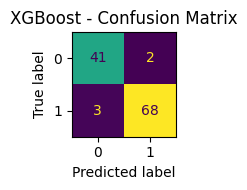

In [390]:
print_confusion_matrix(
    y_test=y_test,
    test_predictions=test_predictions,
    model_name="XGBoost"
)

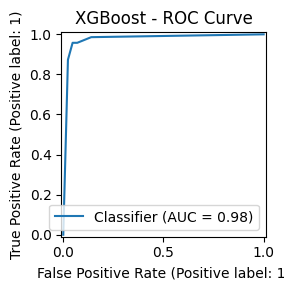

In [391]:
plot_roc_curve(
    y_test=y_test,
    test_probabilities=test_probabilities,
    model_name="XGBoost"
)

In [392]:
comparison_df = compare_train_vs_test(
    y_train=y_train,
    train_predictions=train_predictions,
    y_test=y_test,
    test_predictions=test_predictions
)

comparison_df

,Metric,Training,Test,Difference
0,Accuracy,0.9846,0.9561,0.0285
1,Precision,0.9827,0.9714,0.0113
2,Recall,0.9930,0.9577,0.0353
3,F1 Score,0.9878,0.9645,0.0233


### 5. Gradient Boosting:

In [393]:
gradient_boosting_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", GradientBoostingClassifier(
        random_state=42
    ))
])

In [394]:
cv_results = perform_cross_validation(
    pipeline=gradient_boosting_pipeline,
    X_train=X_train,
    y_train=y_train
)

In [395]:
print_cv_fold_results(cv_results)

,Fold,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,1,0.989011,0.983051,1.000000,0.991453,0.998433
1,2,0.956044,0.949153,0.982456,0.965517,0.980908
2,3,0.923077,0.980769,0.894737,0.935780,0.991744
3,4,0.934066,0.963636,0.929825,0.946429,0.987100
4,5,1.000000,1.000000,1.000000,1.000000,1.000000


In [396]:
print_cv_average_results(cv_results)

Accuracy  : 0.9604
Precision : 0.9753
Recall    : 0.9614
F1 Score  : 0.9678
ROC AUC   : 0.9916


In [397]:
gradient_boosting_trained_pipeline, training_time = fit_pipeline(
    pipeline=gradient_boosting_pipeline,
    X_train=X_train,
    y_train=y_train
)

print(f"Training Time: {training_time:.4f} seconds")

Training Time: 1.6930 seconds


In [398]:
joblib.dump(gradient_boosting_trained_pipeline, "../outputs/models/gradient_boosting.pkl")

['../outputs/models/gradient_boosting.pkl']

In [399]:
(
    train_predictions,
    test_predictions,
    train_probabilities,
    test_probabilities
) = predict_pipeline(
    pipeline=trained_pipeline,
    X_train=X_train,
    X_test=X_test
)

In [400]:
_ = print_test_metrics(
    y_test=y_test,
    test_predictions=test_predictions,
    test_probabilities=test_probabilities
)

Accuracy  : 0.9561
Precision : 0.9714
Recall    : 0.9577
F1 Score  : 0.9645
ROC AUC   : 0.9759


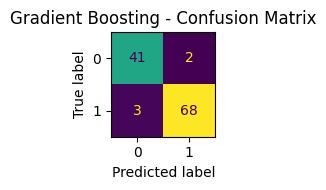

In [401]:
print_confusion_matrix(
    y_test=y_test,
    test_predictions=test_predictions,
    model_name="Gradient Boosting"
)

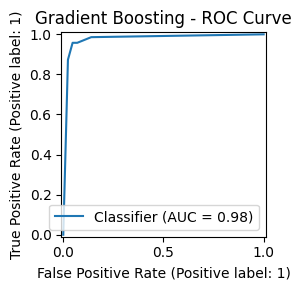

In [402]:
plot_roc_curve(
    y_test=y_test,
    test_probabilities=test_probabilities,
    model_name="Gradient Boosting"
)

In [403]:
comparison_df = compare_train_vs_test(
    y_train=y_train,
    train_predictions=train_predictions,
    y_test=y_test,
    test_predictions=test_predictions
)

comparison_df

,Metric,Training,Test,Difference
0,Accuracy,0.9846,0.9561,0.0285
1,Precision,0.9827,0.9714,0.0113
2,Recall,0.9930,0.9577,0.0353
3,F1 Score,0.9878,0.9645,0.0233


### 6. Support Vector Machine(SVM):

In [404]:
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", SVC(
        probability=True,
        random_state=42
    ))
])

In [405]:
cv_results = perform_cross_validation(
    pipeline=gradient_boosting_pipeline,
    X_train=X_train,
    y_train=y_train
)

In [406]:
print_cv_fold_results(cv_results)

,Fold,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,1,0.989011,0.983051,1.000000,0.991453,0.998433
1,2,0.956044,0.949153,0.982456,0.965517,0.980908
2,3,0.923077,0.980769,0.894737,0.935780,0.991744
3,4,0.934066,0.963636,0.929825,0.946429,0.987100
4,5,1.000000,1.000000,1.000000,1.000000,1.000000


In [407]:
print_cv_average_results(cv_results)

Accuracy  : 0.9604
Precision : 0.9753
Recall    : 0.9614
F1 Score  : 0.9678
ROC AUC   : 0.9916


In [408]:
print_cv_standard_deviation(cv_results)

Accuracy  : 0.0335
Precision : 0.0195
Recall    : 0.0471
F1 Score  : 0.0278
ROC AUC   : 0.0079


In [409]:
svm_trained_pipeline, training_time = fit_pipeline(
    pipeline=svm_pipeline,
    X_train=X_train,
    y_train=y_train
)

print(f"Training Time: {training_time:.4f} seconds")

Training Time: 0.0864 seconds


In [410]:
joblib.dump(svm_trained_pipeline, "../outputs/models/svm.pkl")

['../outputs/models/svm.pkl']

In [411]:
(
    train_predictions,
    test_predictions,
    train_probabilities,
    test_probabilities
) = predict_pipeline(
    pipeline=trained_pipeline,
    X_train=X_train,
    X_test=X_test
)

In [412]:
_= print_test_metrics(
    y_test=y_test,
    test_predictions=test_predictions,
    test_probabilities=test_probabilities
)

Accuracy  : 0.9561
Precision : 0.9714
Recall    : 0.9577
F1 Score  : 0.9645
ROC AUC   : 0.9759


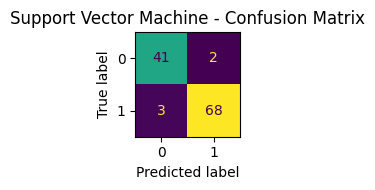

In [413]:
print_confusion_matrix(
    y_test=y_test,
    test_predictions=test_predictions,
    model_name="Support Vector Machine"
)

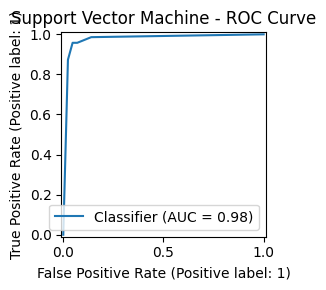

In [414]:
plot_roc_curve(
    y_test=y_test,
    test_probabilities=test_probabilities,
    model_name="Support Vector Machine"
)

In [415]:
comparison_df = compare_train_vs_test(
    y_train=y_train,
    train_predictions=train_predictions,
    y_test=y_test,
    test_predictions=test_predictions
)

comparison_df

,Metric,Training,Test,Difference
0,Accuracy,0.9846,0.9561,0.0285
1,Precision,0.9827,0.9714,0.0113
2,Recall,0.9930,0.9577,0.0353
3,F1 Score,0.9878,0.9645,0.0233


### 7. KNN 

In [416]:
knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", KNeighborsClassifier(
        n_neighbors=5
    ))
])

In [417]:
cv_results = perform_cross_validation(
    pipeline=knn_pipeline,
    X_train=X_train,
    y_train=y_train
)

In [418]:
print_cv_fold_results(cv_results)

,Fold,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,1,0.967033,0.966102,0.982759,0.974359,0.997388
1,2,0.956044,0.949153,0.982456,0.965517,0.981682
2,3,0.967033,0.982143,0.964912,0.973451,0.993808
3,4,0.967033,0.965517,0.982456,0.973913,0.980392
4,5,0.934066,0.932203,0.964912,0.948276,0.994582


In [419]:
print_cv_average_results(cv_results)

Accuracy  : 0.9582
Precision : 0.9590
Recall    : 0.9755
F1 Score  : 0.9671
ROC AUC   : 0.9896


In [420]:
print_cv_standard_deviation(cv_results)

Accuracy  : 0.0143
Precision : 0.0190
Recall    : 0.0097
F1 Score  : 0.0111
ROC AUC   : 0.0079


In [421]:
print_cv_standard_deviation(cv_results)

Accuracy  : 0.0143
Precision : 0.0190
Recall    : 0.0097
F1 Score  : 0.0111
ROC AUC   : 0.0079


In [422]:
knn_trained_pipeline, training_time = fit_pipeline(
    pipeline=knn_pipeline,
    X_train=X_train,
    y_train=y_train
)

print(f"Training Time: {training_time:.4f} seconds")

Training Time: 0.0206 seconds


In [423]:
joblib.dump(knn_trained_pipeline, "../outputs/models/knn.pkl")

['../outputs/models/knn.pkl']

In [424]:
(
    train_predictions,
    test_predictions,
    train_probabilities,
    test_probabilities
) = predict_pipeline(
    pipeline=trained_pipeline,
    X_train=X_train,
    X_test=X_test
)

In [425]:
_ = print_test_metrics(
    y_test=y_test,
    test_predictions=test_predictions,
    test_probabilities=test_probabilities
)

Accuracy  : 0.9561
Precision : 0.9714
Recall    : 0.9577
F1 Score  : 0.9645
ROC AUC   : 0.9759


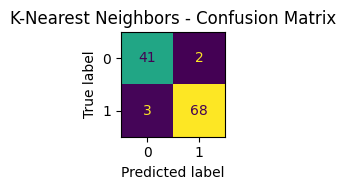

In [426]:
print_confusion_matrix(
    y_test=y_test,
    test_predictions=test_predictions,
    model_name="K-Nearest Neighbors"
)

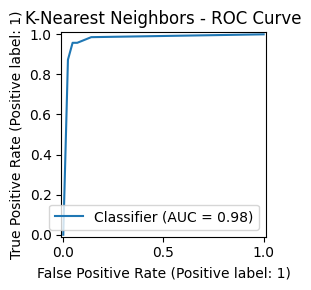

In [427]:
plot_roc_curve(
    y_test=y_test,
    test_probabilities=test_probabilities,
    model_name="K-Nearest Neighbors"
)

In [428]:
comparison_df = compare_train_vs_test(
    y_train=y_train,
    train_predictions=train_predictions,
    y_test=y_test,
    test_predictions=test_predictions
)

comparison_df

,Metric,Training,Test,Difference
0,Accuracy,0.9846,0.9561,0.0285
1,Precision,0.9827,0.9714,0.0113
2,Recall,0.9930,0.9577,0.0353
3,F1 Score,0.9878,0.9645,0.0233


## Comparison of all the models:

In [429]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Dictionary containing all trained models
models = {
    "Logistic Regression": logistic_regression_trained_pipeline,
    "Decision Tree": decision_tree_trained_pipeline,
    "Random Forest": random_forest_trained_pipeline,
    "Gradient Boosting": gradient_boosting_trained_pipeline,
    "XGBoost": xgboost_trained_pipeline,
    "SVM": svm_trained_pipeline,
    "KNN": knn_trained_pipeline
}

# Store results
results = []

for model_name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities for ROC-AUC
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

# Convert to DataFrame
comparison_df = pd.DataFrame(results)

# Round values to 4 decimal places
comparison_df = comparison_df.round(4)

# Display
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9825,0.9859,0.9859,0.9859,0.9974
1,Decision Tree,0.9737,1.0000,0.9577,0.9784,0.9789
2,Random Forest,0.9737,0.9857,0.9718,0.9787,0.9980
3,Gradient Boosting,0.9649,0.9718,0.9718,0.9718,0.9971
4,XGBoost,0.9649,0.9718,0.9718,0.9718,0.9957
5,SVM,0.9737,0.9722,0.9859,0.9790,0.9971
6,KNN,0.9561,0.9714,0.9577,0.9645,0.9759


## Training and Testing Results comparison:

In [430]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    "Logistic Regression": logistic_regression_trained_pipeline,
    "Decision Tree": decision_tree_trained_pipeline,
    "Random Forest": random_forest_trained_pipeline,
    "Gradient Boosting": gradient_boosting_trained_pipeline,
    "XGBoost": xgboost_trained_pipeline,
    "SVM": svm_trained_pipeline,
    "KNN": knn_trained_pipeline
}

results = []

for model_name, model in models.items():

    # =========================
    # Training Predictions
    # =========================
    train_pred = model.predict(X_train)
    train_prob = model.predict_proba(X_train)[:, 1]

    # =========================
    # Test Predictions
    # =========================
    test_pred = model.predict(X_test)
    test_prob = model.predict_proba(X_test)[:, 1]

    # =========================
    # Calculate Metrics
    # =========================
    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)

    train_precision = precision_score(y_train, train_pred)
    test_precision = precision_score(y_test, test_pred)

    train_recall = recall_score(y_train, train_pred)
    test_recall = recall_score(y_test, test_pred)

    train_f1 = f1_score(y_train, train_pred)
    test_f1 = f1_score(y_test, test_pred)

    train_auc = roc_auc_score(y_train, train_prob)
    test_auc = roc_auc_score(y_test, test_prob)

    results.append({
        "Model": model_name,

        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Accuracy Gap": abs(train_accuracy - test_accuracy),

        "Train Precision": train_precision,
        "Test Precision": test_precision,
        "Precision Gap": abs(train_precision - test_precision),

        "Train Recall": train_recall,
        "Test Recall": test_recall,
        "Recall Gap": abs(train_recall - test_recall),

        "Train F1": train_f1,
        "Test F1": test_f1,
        "F1 Gap": abs(train_f1 - test_f1),

        "Train ROC-AUC": train_auc,
        "Test ROC-AUC": test_auc,
        "ROC-AUC Gap": abs(train_auc - test_auc)
    })

comparison_df = pd.DataFrame(results)

# Round all numeric columns
comparison_df = comparison_df.round(4)

comparison_df

,Model,Train Accuracy,Test Accuracy,Accuracy Gap,Train Precision,Test Precision,Precision Gap,Train Recall,Test Recall,Recall Gap,Train F1,Test F1,F1 Gap,Train ROC-AUC,Test ROC-AUC,ROC-AUC Gap
0,Logistic Regression,0.9890,0.9825,0.0066,0.9895,0.9859,0.0036,0.993,0.9859,0.0071,0.9913,0.9859,0.0054,0.9973,0.9974,0.0001
1,Decision Tree,1.0000,0.9737,0.0263,1.0000,1.0000,0.0000,1.000,0.9577,0.0423,1.0000,0.9784,0.0216,1.0000,0.9789,0.0211
2,Random Forest,1.0000,0.9737,0.0263,1.0000,0.9857,0.0143,1.000,0.9718,0.0282,1.0000,0.9787,0.0213,1.0000,0.9980,0.0020
3,Gradient Boosting,1.0000,0.9649,0.0351,1.0000,0.9718,0.0282,1.000,0.9718,0.0282,1.0000,0.9718,0.0282,1.0000,0.9971,0.0029
4,XGBoost,1.0000,0.9649,0.0351,1.0000,0.9718,0.0282,1.000,0.9718,0.0282,1.0000,0.9718,0.0282,1.0000,0.9957,0.0043
5,SVM,0.9846,0.9737,0.0109,0.9827,0.9722,0.0105,0.993,0.9859,0.0071,0.9878,0.9790,0.0088,0.9978,0.9971,0.0007
6,KNN,0.9846,0.9561,0.0285,0.9827,0.9714,0.0113,0.993,0.9577,0.0353,0.9878,0.9645,0.0233,0.9986,0.9759,0.0227


### Selection of best model:

I am considering <b>mainly</b> these metrics for the model selection:

1. <b>Recall:</b> I have learnt that in medical field, it is dangerous that if someone has a disease and model predicts that the patient has no disease. So, the rate of false negatives(recall) should be less.
2. <b>Overfitting:</b> If a model overfits, then it will perform poorly on entirely new data.
3. <b>Accuracy:</b> It shows overall how the model is performing.

Based on these matrices, I have concluded that <b>Logistic Regression</b> is the best model.

#### Reason:

<b>Recall</b>: Logistic Regression has highest recall(98.59%).

<b>Overfitting:</b> It has the lowest train-test gap. Mainly in the case of Recall, the gap between recall during training is 0.0071 and in the case ofAccuracy()